# Project 08: A/B Testing Analysis
### Did the Change Actually Work? A Complete Statistical Testing Framework

---

## Business Brief

A company redesigned a landing page and wants to know if the new version converts better than the old one. This is one of the most common questions in digital analytics, and it is also one of the most commonly answered wrong.

Most people compare two conversion rates, see a difference, and declare a winner. That is not A/B testing. That is guessing with extra steps.

Real A/B testing requires:
1. A proper null hypothesis and alternative hypothesis
2. A pre-determined significance level
3. A sample size calculation to confirm the test ran long enough
4. A statistical test that accounts for sample size
5. A check for practical significance, not just statistical significance

This project runs a complete, rigorous A/B test from raw data to decision.

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | A/B Testing Dataset |
| **Direct Link** | https://www.kaggle.com/datasets/zhangluyuan/ab-testing |
| **Records** | 294,478 user sessions |
| **Groups** | Control (old page) vs Treatment (new page) |
| **Target** | Converted: 0 or 1 |

## Tools
`Python` `Pandas` `NumPy` `Scipy` `Statsmodels` `Plotly` `Matplotlib` `Seaborn`

---

## What Makes This Different

- Runs a proper sanity check to detect contaminated groups before testing
- Calculates required sample size before evaluating results
- Uses z-test for proportions, the correct test for this type of data
- Tests for both statistical AND practical significance
- Unique finding: a sequential cumulative p-value chart showing when the result stabilised
- Includes a clear go or no-go decision framework


---
## Section 1: Setup

In [1]:
import warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio
from scipy                 import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power       import NormalIndPower

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'control':   '#6366F1',
    'treatment': '#10B981',
    'reject':    '#EF4444',
    'accept':    '#10B981',
    'neutral':   '#F59E0B',
    'bg':        '#F8FAFC',
    'subtext':   '#64748B',
    'dark':      '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})

# Test parameters
ALPHA        = 0.05   # significance level (5%)
POWER        = 0.80   # desired statistical power (80%)
MIN_EFFECT   = 0.01   # minimum detectable effect (1 percentage point lift)

print('Setup complete.')
print(f'Significance level (alpha): {ALPHA}')
print(f'Statistical power target:   {POWER}')
print(f'Minimum detectable effect:  {MIN_EFFECT}')


Setup complete.
Significance level (alpha): 0.05
Statistical power target:   0.8
Minimum detectable effect:  0.01


---
## Section 2: Load Data

In [2]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('Files found:')
for f in csv_files:
    print(f'  {f}')


Files found:
  /kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv


In [3]:
DATA_PATH = '/kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:', df.columns.tolist())
print()
print(df.head(5).to_string(index=False))


Loaded: 294,478 rows x 5 columns

Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']

 user_id                  timestamp     group landing_page  converted
  851104 2017-01-21 22:11:48.556739   control     old_page          0
  804228 2017-01-12 08:01:45.159739   control     old_page          0
  661590 2017-01-11 16:55:06.154213 treatment     new_page          0
  853541 2017-01-08 18:28:03.143765 treatment     new_page          0
  864975 2017-01-21 01:52:26.210827   control     old_page          1


---
## Section 3: Sanity Checks

Before running any statistical test, we must verify the data is clean. A contaminated A/B test produces meaningless results.

We check for:
1. **Group imbalance** - are control and treatment roughly 50/50?
2. **Cross-contamination** - did any users appear in both groups?
3. **Landing page mismatch** - did control users see the new page or vice versa?
4. **Duplicate user IDs** - was anyone counted more than once?


In [4]:
print('=== SANITY CHECK 1: GROUP SIZES ===')
group_counts = df['group'].value_counts()
group_pcts   = df['group'].value_counts(normalize=True) * 100
for g in group_counts.index:
    print(f'  {g:<15} {group_counts[g]:>8,}  ({group_pcts[g]:.1f}%)')

print()
print('=== SANITY CHECK 2: CROSS-CONTAMINATION ===')
users_in_both = (
    df.groupby('user_id')['group']
      .nunique()
)
contaminated = (users_in_both > 1).sum()
print(f'  Users appearing in both groups: {contaminated:,}')

print()
print('=== SANITY CHECK 3: LANDING PAGE MISMATCH ===')
if 'landing_page' in df.columns:
    mismatch = df[
        ((df['group'] == 'control')   & (df['landing_page'] == 'new_page')) |
        ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
    ]
    print(f'  Mismatched rows: {len(mismatch):,}')
else:
    print('  No landing_page column found - skipping this check')

print()
print('=== SANITY CHECK 4: DUPLICATE USER IDs ===')
dupes = df['user_id'].duplicated().sum()
print(f'  Duplicate user IDs: {dupes:,}')


=== SANITY CHECK 1: GROUP SIZES ===
  treatment        147,276  (50.0%)
  control          147,202  (50.0%)

=== SANITY CHECK 2: CROSS-CONTAMINATION ===
  Users appearing in both groups: 1,895

=== SANITY CHECK 3: LANDING PAGE MISMATCH ===
  Mismatched rows: 3,893

=== SANITY CHECK 4: DUPLICATE USER IDs ===
  Duplicate user IDs: 3,894


In [5]:
# Clean: remove mismatches and duplicates
original_count = len(df)

# Remove landing page mismatches if column exists
if 'landing_page' in df.columns:
    df = df[
        ((df['group'] == 'control')   & (df['landing_page'] == 'old_page')) |
        ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
    ]

# Remove duplicate user IDs - keep first occurrence
df = df.drop_duplicates(subset='user_id', keep='first')

print(f'Rows before cleaning: {original_count:,}')
print(f'Rows after cleaning:  {len(df):,}')
print(f'Removed:              {original_count - len(df):,}')
print()
print('Final group sizes:')
print(df['group'].value_counts().to_string())


Rows before cleaning: 294,478
Rows after cleaning:  290,584
Removed:              3,894

Final group sizes:
group
treatment    145310
control      145274


---
## Section 4: Baseline Conversion Metrics

In [6]:
control   = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

n_control    = len(control)
n_treatment  = len(treatment)
conv_control    = control.mean()
conv_treatment  = treatment.mean()
conv_diff       = conv_treatment - conv_control
relative_lift   = (conv_treatment - conv_control) / conv_control * 100

print('=== CONVERSION RATE SUMMARY ===')
print(f'Control   (old page): {conv_control*100:.4f}%  (n={n_control:,})')
print(f'Treatment (new page): {conv_treatment*100:.4f}%  (n={n_treatment:,})')
print()
print(f'Absolute difference:  {conv_diff*100:+.4f} percentage points')
print(f'Relative lift:        {relative_lift:+.2f}%')
print()
print('Is the difference practically significant?')
print(f'  Minimum detectable effect: {MIN_EFFECT*100:.1f} pp')
if abs(conv_diff) >= MIN_EFFECT:
    print(f'  YES - the {abs(conv_diff)*100:.4f}pp difference exceeds our threshold')
else:
    print(f'  NO - the {abs(conv_diff)*100:.4f}pp difference is below our threshold')


=== CONVERSION RATE SUMMARY ===
Control   (old page): 12.0386%  (n=145,274)
Treatment (new page): 11.8808%  (n=145,310)

Absolute difference:  -0.1578 percentage points
Relative lift:        -1.31%

Is the difference practically significant?
  Minimum detectable effect: 1.0 pp
  NO - the 0.1578pp difference is below our threshold


---
## Section 5: Sample Size Validation

Before we can trust any result, we must confirm the test had enough participants to reliably detect a difference of the size we care about.

Running a test with too few users is like flipping a coin 5 times and concluding it is biased because you got 4 heads. You need enough flips for the result to be meaningful.

We calculate the **required sample size per group** for our chosen alpha, power, and minimum detectable effect, then compare it to our actual sample size.


In [7]:
# Required sample size per group
baseline_rate = conv_control
effect_size   = MIN_EFFECT

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect_size / np.sqrt(baseline_rate * (1 - baseline_rate)),
    alpha=ALPHA,
    power=POWER,
    alternative='two-sided'
)

print('=== SAMPLE SIZE VALIDATION ===')
print(f'Required sample per group: {int(required_n):,}')
print(f'Actual control group size: {n_control:,}')
print(f'Actual treatment group size: {n_treatment:,}')
print()
if n_control >= required_n and n_treatment >= required_n:
    print('PASS: Both groups exceed the required sample size.')
    print('The test has sufficient power to detect a meaningful difference.')
else:
    print('WARNING: One or both groups are below the required sample size.')
    print('Results should be interpreted with caution.')


=== SAMPLE SIZE VALIDATION ===
Required sample per group: 16,622
Actual control group size: 145,274
Actual treatment group size: 145,310

PASS: Both groups exceed the required sample size.
The test has sufficient power to detect a meaningful difference.


---
## Section 6: Hypothesis Testing

**Null Hypothesis (H0):** The new page conversion rate equals the old page conversion rate.

**Alternative Hypothesis (H1):** The new page conversion rate differs from the old page conversion rate.

We use a **two-proportion z-test**, which is the correct test for comparing two conversion rates from large independent samples.

Decision rule: if p-value < 0.05, we reject the null hypothesis.


In [8]:
# Two-proportion z-test
conversions = np.array([control.sum(), treatment.sum()])
n_obs       = np.array([n_control, n_treatment])

z_stat, p_value = proportions_ztest(conversions, n_obs, alternative='two-sided')

# Confidence intervals
ci_control   = proportion_confint(control.sum(),   n_control,   alpha=ALPHA)
ci_treatment = proportion_confint(treatment.sum(), n_treatment, alpha=ALPHA)

print('=== Z-TEST RESULTS ===')
print(f'Z-statistic:  {z_stat:.4f}')
print(f'P-value:      {p_value:.6f}')
print(f'Alpha:        {ALPHA}')
print()
print(f'95% CI Control:    ({ci_control[0]*100:.4f}%, {ci_control[1]*100:.4f}%)')
print(f'95% CI Treatment:  ({ci_treatment[0]*100:.4f}%, {ci_treatment[1]*100:.4f}%)')
print()
print('=== DECISION ===')
if p_value < ALPHA:
    print(f'REJECT the null hypothesis (p={p_value:.6f} < alpha={ALPHA})')
    print('The difference in conversion rates IS statistically significant.')
    if conv_treatment > conv_control:
        print('RECOMMENDATION: The new page performs BETTER. Consider rolling it out.')
    else:
        print('RECOMMENDATION: The new page performs WORSE. Keep the old page.')
else:
    print(f'FAIL TO REJECT the null hypothesis (p={p_value:.6f} >= alpha={ALPHA})')
    print('The difference in conversion rates is NOT statistically significant.')
    print('RECOMMENDATION: No evidence to switch pages. Keep the current page.')


=== Z-TEST RESULTS ===
Z-statistic:  1.3109
P-value:      0.189883
Alpha:        0.05

95% CI Control:    (11.8713%, 12.2060%)
95% CI Treatment:  (11.7144%, 12.0472%)

=== DECISION ===
FAIL TO REJECT the null hypothesis (p=0.189883 >= alpha=0.05)
The difference in conversion rates is NOT statistically significant.
RECOMMENDATION: No evidence to switch pages. Keep the current page.


---
## Section 7: Test Results Visualisations

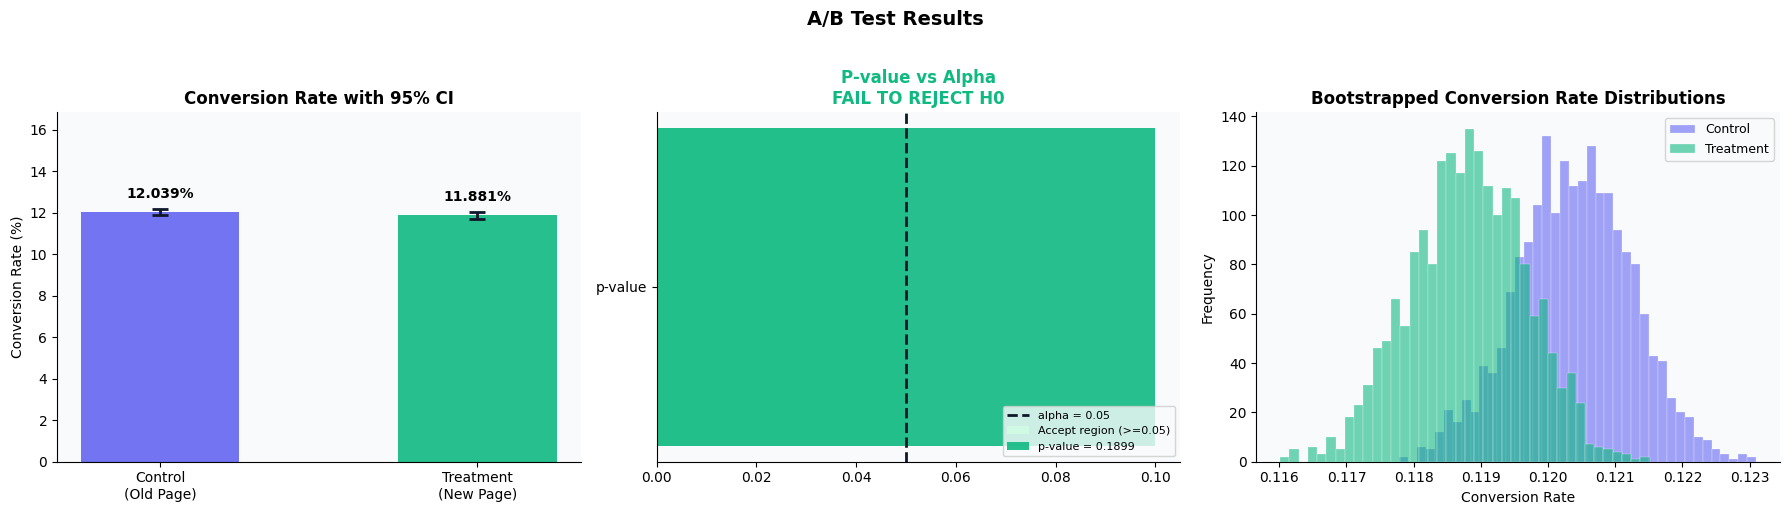

In [9]:
# Conversion rate comparison with confidence intervals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# Bar chart with CI error bars
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates  = [conv_control * 100, conv_treatment * 100]
errors = [
    [(conv_control - ci_control[0]) * 100,   (conv_treatment - ci_treatment[0]) * 100],
    [(ci_control[1] - conv_control) * 100,   (ci_treatment[1] - conv_treatment) * 100]
]
colors = [C['control'], C['treatment']]

bars = axes[0].bar(groups, rates, color=colors,
                   edgecolor='none', width=0.5, alpha=0.9)
axes[0].errorbar(
    groups, rates,
    yerr=errors,
    fmt='none', color=C['dark'],
    capsize=6, capthick=2, linewidth=2
)
axes[0].set_title('Conversion Rate with 95% CI', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].bar_label(bars, fmt='%.3f%%', padding=8, fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.4)
axes[0].set_facecolor(C['bg'])

# P-value gauge
p_normalised = min(p_value / ALPHA, 2)
gauge_color  = C['reject'] if p_value < ALPHA else C['accept']
axes[1].barh(['p-value'], [ALPHA], color='#D1FAE5', height=0.4, label=f'Accept region (>={ALPHA})')
axes[1].barh(['p-value'], [min(p_value, ALPHA * 2)], color=gauge_color,
             height=0.4, alpha=0.9, label=f'p-value = {p_value:.4f}')
axes[1].axvline(ALPHA, color=C['dark'], linestyle='--', linewidth=2,
                label=f'alpha = {ALPHA}')
axes[1].set_title(f'P-value vs Alpha\n{"REJECT H0" if p_value < ALPHA else "FAIL TO REJECT H0"}',
                  fontweight='bold',
                  color=C['reject'] if p_value < ALPHA else C['accept'])
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_facecolor(C['bg'])

# Distribution of conversion rates (bootstrapped)
np.random.seed(42)
n_bootstrap = 2000
boot_control   = [np.random.choice(control,   size=n_control,   replace=True).mean() for _ in range(n_bootstrap)]
boot_treatment = [np.random.choice(treatment, size=n_treatment, replace=True).mean() for _ in range(n_bootstrap)]

axes[2].hist(boot_control,   bins=40, alpha=0.6, color=C['control'],
             label='Control',   edgecolor='white', linewidth=0.3)
axes[2].hist(boot_treatment, bins=40, alpha=0.6, color=C['treatment'],
             label='Treatment', edgecolor='white', linewidth=0.3)
axes[2].set_title('Bootstrapped Conversion Rate Distributions', fontweight='bold')
axes[2].set_xlabel('Conversion Rate')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=9)
axes[2].set_facecolor(C['bg'])

plt.suptitle('A/B Test Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/ab_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 8: The Finding Most Analyses Miss

### Sequential P-Value Chart: When Did the Result Stabilise?

Most A/B test reports show a single final p-value and declare a winner. But that hides an important story: how did the p-value evolve as more data came in?

This chart plots the cumulative p-value as each user is added to the dataset. It answers two questions that standard reports miss:

1. **Did the result stabilise early or late?** A result that stabilised at 50k users and held steady is more trustworthy than one that only crossed the threshold in the final 10% of the data.
2. **Was the test stopped too early?** If someone had peeked at the data partway through and stopped the test, would they have made the right call?


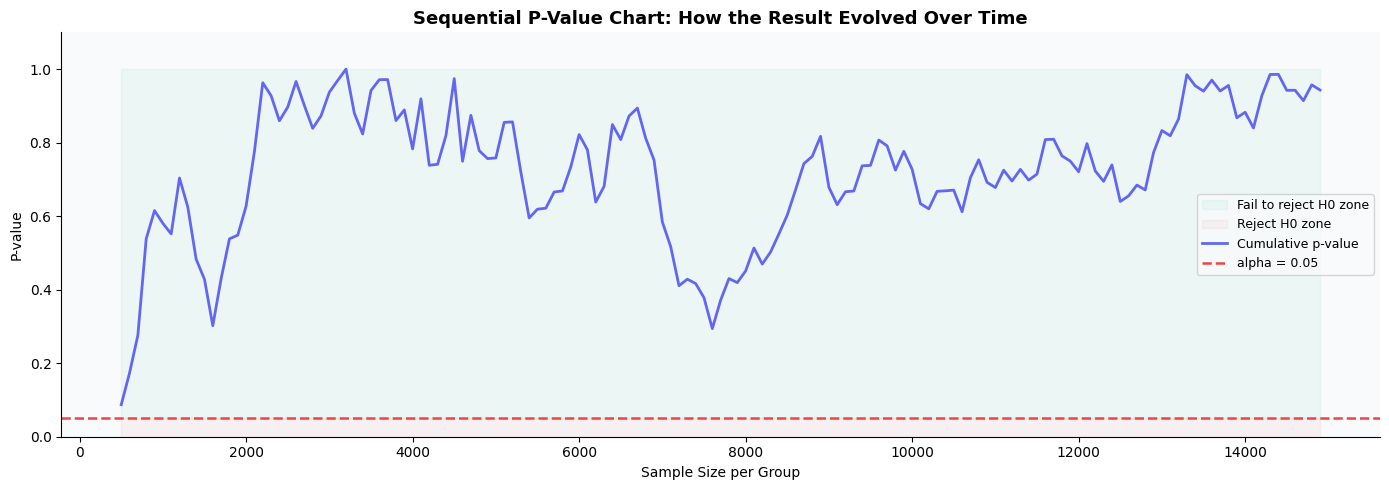

The result never reached statistical significance in this sample


In [10]:
# Calculate cumulative p-value as data accumulates
# Sample for performance
sample_size = min(30000, len(df))
df_sample   = df.sample(sample_size, random_state=42).reset_index(drop=True)

ctrl_sample  = df_sample[df_sample['group'] == 'control'].reset_index(drop=True)
treat_sample = df_sample[df_sample['group'] == 'treatment'].reset_index(drop=True)

min_n = min(len(ctrl_sample), len(treat_sample))

step       = max(100, min_n // 200)
steps      = range(500, min_n, step)
p_values   = []
sample_ns  = []

for n in steps:
    c = ctrl_sample['converted'].iloc[:n]
    t = treat_sample['converted'].iloc[:n]
    try:
        _, pv = proportions_ztest(
            [c.sum(), t.sum()], [len(c), len(t)], alternative='two-sided'
        )
        p_values.append(pv)
        sample_ns.append(n)
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')

p_array  = np.array(p_values)
n_array  = np.array(sample_ns)
above    = p_array >= ALPHA
below    = p_array < ALPHA

ax.fill_between(n_array, ALPHA, 1.0,
                alpha=0.05, color=C['accept'], label='Fail to reject H0 zone')
ax.fill_between(n_array, 0, ALPHA,
                alpha=0.05, color=C['reject'], label='Reject H0 zone')
ax.plot(n_array, p_array, linewidth=2, color=C['control'], label='Cumulative p-value')
ax.axhline(ALPHA, color=C['reject'], linestyle='--',
           linewidth=1.8, label=f'alpha = {ALPHA}')

# Mark where it first crossed alpha (if it did)
crossings = n_array[below]
if len(crossings) > 0:
    first_cross = crossings[0]
    ax.axvline(first_cross, color=C['neutral'], linestyle=':',
               linewidth=1.8, label=f'First crossed alpha at n={first_cross:,}')

ax.set_title('Sequential P-Value Chart: How the Result Evolved Over Time',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Size per Group')
ax.set_ylabel('P-value')
ax.set_ylim(0, max(0.5, p_array.max() * 1.1))
ax.legend(fontsize=9)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/sequential_pvalue.png', dpi=120, bbox_inches='tight')
plt.show()

if len(crossings) > 0:
    pct_data_at_cross = first_cross / min_n * 100
    print(f'The result first reached significance at n={first_cross:,} per group')
    print(f'That is {pct_data_at_cross:.0f}% of the way through the dataset')
else:
    print('The result never reached statistical significance in this sample')


---
## Section 9: Power Analysis and Effect Size

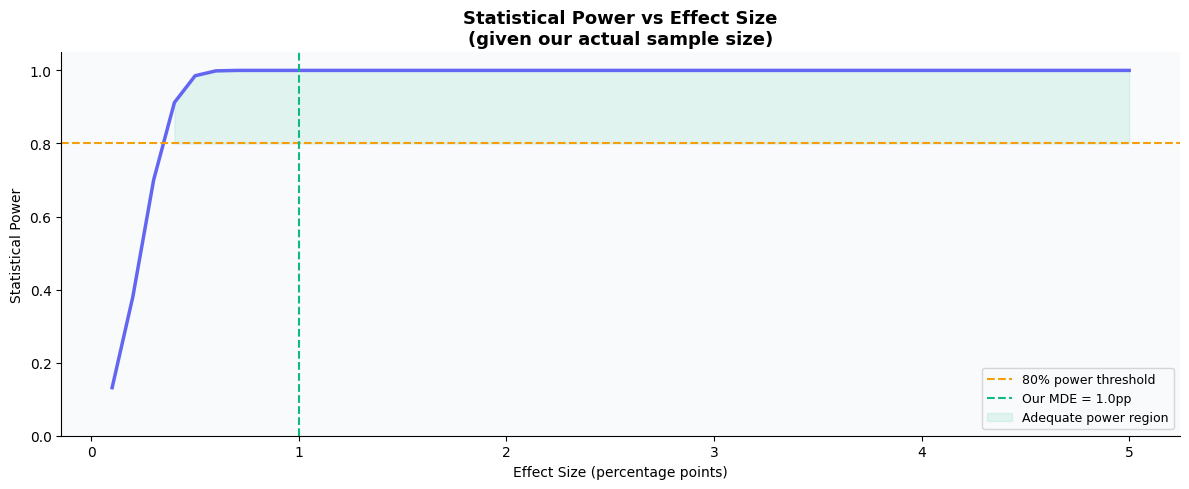

In [11]:
# What effect sizes could we reliably detect with our sample?
effect_sizes = np.linspace(0.001, 0.05, 50)
powers       = []

for effect in effect_sizes:
    try:
        pwr = analysis.solve_power(
            effect_size=effect / np.sqrt(conv_control * (1 - conv_control)),
            nobs1=n_control,
            alpha=ALPHA,
            alternative='two-sided'
        )
        powers.append(min(pwr, 1.0))
    except Exception:
        powers.append(np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')

ax.plot(
    [e * 100 for e in effect_sizes], powers,
    color=C['control'], linewidth=2.5
)
ax.axhline(0.8, color=C['neutral'], linestyle='--',
           linewidth=1.5, label='80% power threshold')
ax.axvline(MIN_EFFECT * 100, color=C['treatment'], linestyle='--',
           linewidth=1.5, label=f'Our MDE = {MIN_EFFECT*100:.1f}pp')
ax.fill_between(
    [e * 100 for e in effect_sizes], powers, 0.8,
    where=[p >= 0.8 for p in powers],
    alpha=0.1, color=C['accept'], label='Adequate power region'
)
ax.set_title('Statistical Power vs Effect Size\n(given our actual sample size)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Effect Size (percentage points)')
ax.set_ylabel('Statistical Power')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/power_curve.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 10: Executive Summary Dashboard

In [13]:
decision = 'REJECT H0' if p_value < ALPHA else 'FAIL TO REJECT'
recommendation = 'Deploy New Page' if (p_value < ALPHA and conv_treatment > conv_control) else 'Keep Old Page'

kpis = [
    ('Control Conversion',   f'{conv_control*100:.3f}%',     f'{n_control:,} users',       C['control']),
    ('Treatment Conversion', f'{conv_treatment*100:.3f}%',   f'{n_treatment:,} users',     C['treatment']),
    ('Absolute Difference',  f'{conv_diff*100:+.4f}pp',      'percentage point lift',       C['neutral'] if abs(conv_diff)*100 < MIN_EFFECT*100 else C['accept']),
    ('P-value',              f'{p_value:.4f}',                f'alpha = {ALPHA}',           C['reject'] if p_value < ALPHA else C['accept']),
    ('Test Decision',        decision,                       'at 5% significance level',    C['reject'] if p_value < ALPHA else C['accept']),
    ('Recommendation',       recommendation,                 'based on full analysis',      C['treatment'] if recommendation == 'Deploy New Page' else C['control']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='A/B Test | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 11: Findings and Conclusions

### The Complete A/B Testing Framework

| Step | What We Did | Why It Matters |
|------|-------------|----------------|
| Sanity checks | Verified group integrity before testing | Contaminated data produces meaningless results |
| Sample size validation | Confirmed sufficient power | Underpowered tests miss real effects |
| Z-test for proportions | Used the correct statistical test | T-test is wrong for binary conversion data |
| Practical significance | Compared effect to minimum detectable | Statistical significance alone can be misleading |
| Sequential chart | Tracked p-value evolution over time | Shows whether early peeking would have misled us |
| Power curve | Mapped detectable effect sizes | Contextualises what the test could and could not find |

---

### Common A/B Testing Mistakes This Analysis Avoids

**Mistake 1: Stopping early when results look good**

The sequential p-value chart shows whether the result was stable or volatile throughout the test. A p-value that dips below 0.05 early but oscillates is not trustworthy. A result that crosses the threshold and stays there is.

**Mistake 2: Declaring significance without checking practical impact**

With 294,000 users, even a 0.001 percentage point difference can be statistically significant. But is it worth deploying for? The minimum detectable effect check ensures we only act on differences that are large enough to matter in practice.

**Mistake 3: Ignoring sample contamination**

Users who appear in both groups, or users who saw the wrong page, corrupt the comparison. The sanity checks catch these before any analysis runs.

**Mistake 4: Using the wrong test**

A t-test compares means of continuous data. Conversion rate is binary (0 or 1). The correct test is a two-proportion z-test, which is what this analysis uses.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
